In [1]:
from datasets import load_dataset, Dataset, Image as Img
import glob
import os
import cv2
from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import io

from torch.utils.data import DataLoader
from IPython.display import clear_output
import random
import torchvision

from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"


NUM_POINTS = 500

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x) * 200 - 100
    amount = amount.view(-1, 1, 1)  # sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

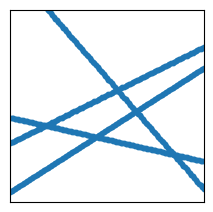

In [4]:


def plot_data(data):
    my_dpi = 100
    fig, ax = plt.subplots(frameon=False, figsize=(250/my_dpi, 250/my_dpi), dpi=my_dpi)
    ax.scatter(data[0], data[1], s=10)
    ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False) 
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.autoscale(tight=True)
    ax.set_ylim(-100, 100)
    
    return fig


def plot_data_batched(data):
    out = []
    for i in data:
        out.append(plot_data(i))
    return out


def generate_data(num_points, lines_count):
    out = None
    for i in range(lines_count):
        x = torch.linspace(-100, 100, num_points//lines_count)
        k = random.random()*4 - 2
        n = random.randint(-50, 50)
        y = k * x + n
        # noise = torch.rand_like(y)
        # y = y * (1 - amount) + noise * amount
        if(out == None):
            out = torch.vstack((x,y))
        else:
            out = torch.hstack((out,torch.vstack((x,y))))
    return out

data = generate_data(NUM_POINTS, 4)
fig = plot_data(data)
fig.show()


torch.Size([2, 500]) <class 'torch.Tensor'>


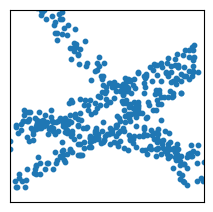

In [5]:
print(data.shape, type(data))
plot_data(corrupt(data.unsqueeze(0), torch.ones(data.shape).unsqueeze(0)*0.1)[0]).show()

In [6]:
def get_image_from_fig(fig:plt.figure):
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    image_np = np.frombuffer(buf.getbuffer(), np.uint8)
    plt.close(fig)
    return cv2.imdecode(image_np, cv2.IMREAD_GRAYSCALE)

data = get_image_from_fig(fig)
data.shape

def get_image_from_fig_batched(figs):
    out = []
    for i in figs:
        out.append(get_image_from_fig(i))
    
    plt.clf()
    plt.close('all')
    return torch.from_numpy(np.array(out)).unsqueeze(1)


In [7]:
from typing import List


class PointsDataset(Dataset):
    def __init__(self, num_points:int, num_lines:int):
        self.num_points = num_points
        self.num_lines = num_lines
        
    def __len__(self):
        return 5000

    def __getitem__(self, idx):
        item = torch.vstack([generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in idx])
        return item
    
    def __getitems__(self, keys: List) -> List:
        return [generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in keys]

train_dataset = PointsDataset(NUM_POINTS, 4)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=24)

0it [00:00, ?it/s]/tmp/ipykernel_5677/3854483525.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(frameon=False, figsize=(250/my_dpi, 250/my_dpi), dpi=my_dpi)
/home/lanv/venv/lib64/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv2d(input, weight, bias, self.stride,
/home/lanv/venv/lib64/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATe

Finished epoch 0. Average loss for this epoch: 542.751906


49it [01:36,  1.98s/it]


KeyboardInterrupt: 

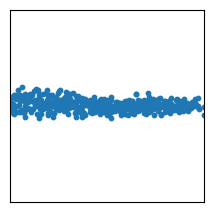

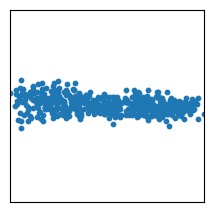

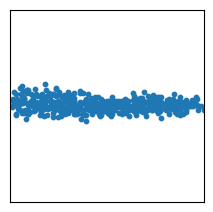

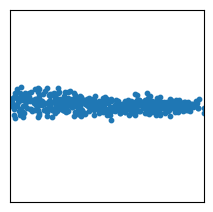

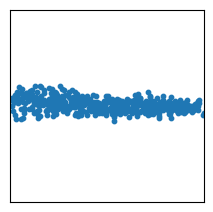

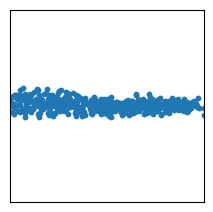

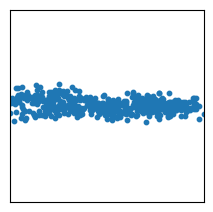

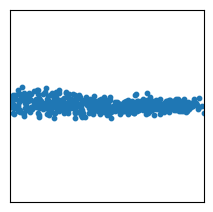

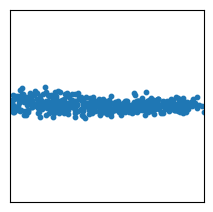

<Figure size 250x250 with 0 Axes>

In [8]:
from model import PointDefussionNet

#  How many runs through the data should we do?
n_epochs = 50

# Create the netork
net = PointDefussionNet(NUM_POINTS, 2)
net.to(device)

# Our loss function
huber = torch.nn.HuberLoss()
def loss_fn(y_hat, y, pixle_diff):
    out = huber(y_hat, y)

    return out * pixle_diff
    
# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for i, x in tqdm(enumerate(train_dataloader)):

        # Get some data and prepare the corrupted version
        noise_amount = torch.rand(x.shape[0]) * 0.8  # Pick random noise amounts
        noised_x = corrupt(x, noise_amount)  # Create our noisy x

        with plt.ioff():
            rendered_noisy = get_image_from_fig_batched(plot_data_batched(noised_x)).to(device).float()
            rendered_target =  get_image_from_fig_batched(plot_data_batched(x)).to(device).float()

        # print(rendered_noisy.shape, rendered_target.shape, noisy_x.shape, x.shape)
        # print(rendered_noisy.dtype, rendered_target.dtype, noisy_x.dtype, x.dtype)

        # Get the model prediction
        pred = net(rendered_target, rendered_noisy, noised_x.to(device))

        # Render predictions
        rendered_pred = get_image_from_fig_batched(plot_data_batched(pred.cpu().detach().numpy())).to(device).float()

        # print(pred.shape, x.shape, noisy_x.shape)
        # Calculate the loss
        pixle_diff = torch.sum(torch.square(rendered_pred - rendered_target)) / 250.0
        loss = loss_fn(pred, x.to(device), pixle_diff)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())
        
        if(i%1000 == 0):
            # fig, axs = plt.subplots(1,3, figsize=(5,5))

            # clear_output()
            # xc = x.detach().cpu().numpy()
            # nxc = noisy_x.detach().cpu().numpy()
            # pc = pred.detach().cpu().numpy()

            # axs[0].scatter(xc[0][0], xc[0][1])
            # axs[1].scatter(nxc[0][0], nxc[0][1])
            # axs[2].scatter(pc[0][0], pc[0][1])

            # fig.show()
            # plt.show()

            # Print our the average of the loss values for this epoch:
            avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
            print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}")


    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}")

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1)

In [ ]:
save_path = "models/pointImgDefussor"
# Save model
# torch.save(net.state_dict(), save_path)

# Load model
net.load_state_dict(torch.load(save_path))
net.eval()

PointDefussionNet(
  (curr_enc): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=63504, out_features=256, bias=True)
  )
  (point_enc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1000, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): ReLU()
  )
  (merge): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1000, bias=True)
  )
)

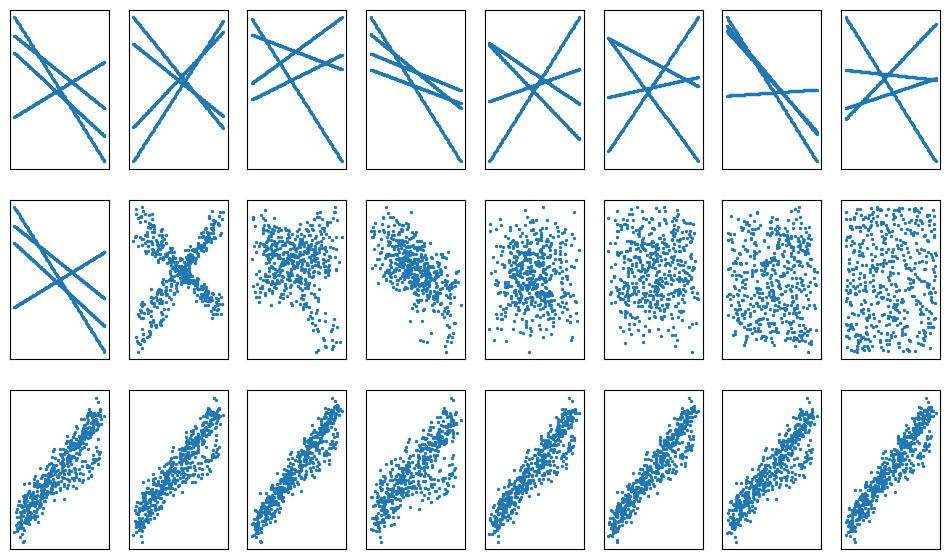

In [ ]:
# @markdown Visualizing model predictions on noisy inputs:

# Fetch some data
x = next(iter(train_dataloader))
x = x[:8]  # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Get the model predictions
with torch.no_grad():
    with plt.ioff():
        rendered_noisy = get_image_from_fig_batched(plot_data_batched(noised_x)).to(device).float()
        rendered_target =  get_image_from_fig_batched(plot_data_batched(x)).to(device).float()
        pred = net(rendered_target, rendered_noisy, noised_x.to(device)).detach().cpu().numpy()

# Plot
fig, axs = plt.subplots(3, x.shape[0], figsize=(12, 7))
for i, data in enumerate(x):
    axs[0][i].scatter(data[0], data[1], s=2)
    axs[0][i].get_xaxis().set_visible(False)
    axs[0][i].get_yaxis().set_visible(False)

for i, data in enumerate(noised_x):
    axs[1][i].scatter(data[0], data[1], s=2)
    axs[1][i].get_xaxis().set_visible(False)
    axs[1][i].get_yaxis().set_visible(False)

for i, data in enumerate(pred):
    axs[2][i].scatter(data[0], data[1], s=2)
    axs[2][i].get_xaxis().set_visible(False)
    axs[2][i].get_yaxis().set_visible(False)
# axs[1].set_title("Corrupted 

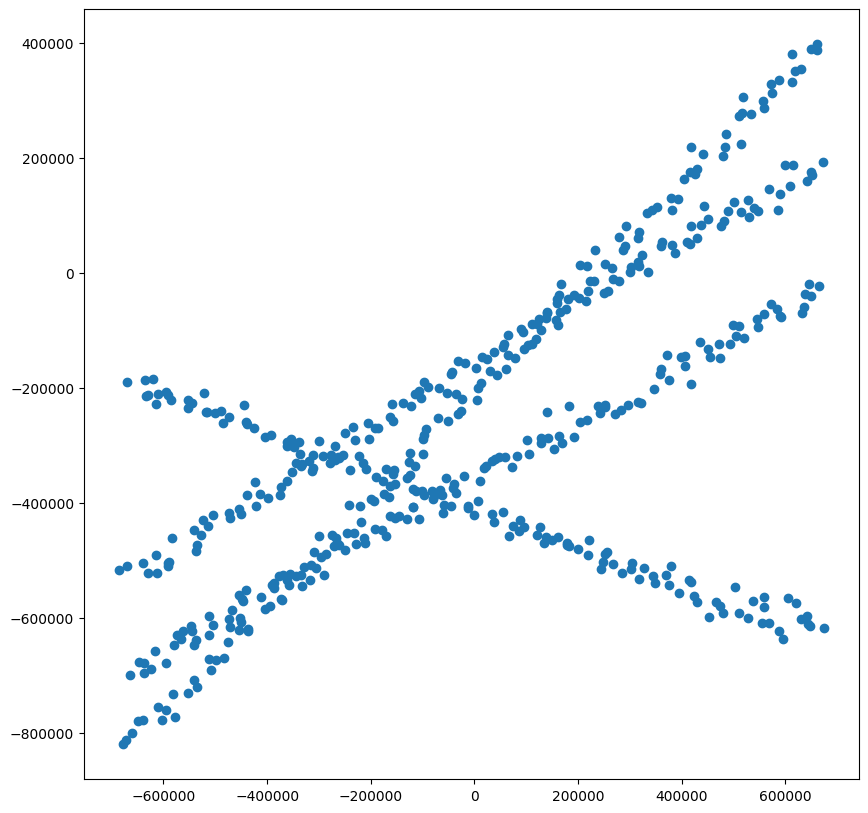

In [ ]:
n_steps = 50
x = torch.rand(1, 2, NUM_POINTS).to(device)

for i in range(n_steps):
    noise_amount = torch.ones((x.shape[0],)).to(device) * (1 - (i / n_steps))  # Starting high going low
    with torch.no_grad():
        with plt.ioff():
            rendered_noisy = get_image_from_fig_batched(plot_data_batched(x.cpu())).to(device).float()
            rendered_target =  get_image_from_fig_batched(plot_data_batched(x.cpu())).to(device).float()
            pred = net(rendered_target, rendered_noisy, x.to(device)).detach().cpu().numpy()
    mix_factor = 1 / (n_steps - i)
    x = x.cpu()* (1 - mix_factor) + pred* mix_factor

x = x.squeeze(0).detach().cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(x[0], x[1])